# CAPSTONE PROJECT CODING CAMP

### ID Tim Capstone Project :   [CC26-PSU338]
### Tema Capstone :   [Accessible & Adaptive Learning]
### Nama/Judul Proyek : [EduPath AI: Platform Belajar Personal  berbasis Adaptive Recommendation]


### List Anggota  :  
1. (CFCC525D6Y0122) - (Fachry Dwi Zakaria) - (Full-Stack Web Developer) -
[Aktif]
2. (CFCC702D6X2062) - (Tyas Firda Hasanah)- (Full Stack Web Developer) -
[Aktif]
3. (CACC452D6Y0957) - (Muhammad Fikri Dwi Saputra)- (AI Engineer) - [Aktif]
4. (CACC452D6X2598) - (Idelia Fitri Kyla)- (AI Engineer) - [Aktif]
5. (CDCC229D6X2501) - (Elina Sianipar)- (Data Scientist) - [Aktif]
6. (CDCC229D6X2021) - (Fadhilah Aulia Zulfa)- (Data Scientist) - [Aktif]

### Menentukan Pertanyaan Bisnis

Pertanyaan Bisnis:

1. Aktivitas digital apa (melihat pengumuman vs membuka modul) yang paling akurat memprediksi siswa akan masuk ke kategori nilai tinggi (Class H), dan berapa ambang batas minimalnya?
2. Seberapa besar pengaruh kombinasi jumlah absen (StudentAbsenceDays) dan rendahnya partisipasi diskusi terhadap risiko siswa mendapatkan nilai rendah (Class L)?
3. Topik pelajaran (Topic) mana yang memiliki tingkat kesulitan tertinggi bagi siswa laki-laki vs perempuan, dan bagaimana pola interaksi yang berhasil di topik tersebut?


### Import Semua Packages/Library yang Digunakan

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

## Data Wrangling

**Gathering Data**

In [79]:
df = pd.read_csv('/content/xAPI-Edu-Data.csv')
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [80]:
df.shape

(480, 17)

In [81]:
df.columns

Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='object')

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

In [83]:
df.describe()

,raisedhands,VisITedResources,AnnouncementsView,Discussion
count,480.000000,480.000000,480.000000,480.000000
mean,46.775000,54.797917,37.918750,43.283333
std,30.779223,33.080007,26.611244,27.637735
min,0.000000,0.000000,0.000000,1.000000
25%,15.750000,20.000000,14.000000,20.000000
50%,50.000000,65.000000,33.000000,39.000000
75%,75.000000,84.000000,58.000000,70.000000
max,100.000000,99.000000,98.000000,99.000000


In [84]:
df['Class'].value_counts()

,count
Class,
M,211
H,142
L,127


**Assessing Data**

In [85]:
df.isnull().sum()

,0
gender,0
NationalITy,0
PlaceofBirth,0
StageID,0
GradeID,0
SectionID,0
Topic,0
Semester,0
Relation,0
raisedhands,0


In [86]:
df.duplicated().sum()

np.int64(2)

**Cleaning Data**

In [87]:
df.drop_duplicates(inplace=True)

In [88]:
df.shape

(478, 17)

In [89]:
df.duplicated().sum()

np.int64(0)

In [90]:
df.describe()

,raisedhands,VisITedResources,AnnouncementsView,Discussion
count,478.000000,478.000000,478.000000,478.000000
mean,46.887029,54.974895,38.014644,43.410042
std,30.787903,33.035071,26.623507,27.620961
min,0.000000,0.000000,0.000000,1.000000
25%,16.000000,20.000000,14.250000,20.000000
50%,50.000000,65.000000,33.000000,39.500000
75%,75.000000,84.000000,58.000000,70.000000
max,100.000000,99.000000,98.000000,99.000000


In [91]:
df["Class"].value_counts()

,count
Class,
M,211
H,142
L,125


**INSIGHT**


1. Struktur dan Kondisi Data
Dataset sudah bersih, lengkap, dan siap digunakan untuk analisis atau model machine learning.
      * Jumlah data awal: 480 baris dan 17 kolom
      * Jumlah data setelah pembersihan: 478 baris dan 17 kolom berarti ada 2 data duplikat yang berhasil diapus
      * Tidak ada nilai null (missing value) diseluruh kolom


2. Tipe Data
      * 13 kolom bertipe object (String)
      * 4 kolom bertipe numerik


3. Distribusi kelas siswa
Aktivitas siswa dalam platform (raised hands, visited resources, dsb.) kemungkinan memiliki korelasi positif dengan kelas performa (H, M, L) bisa dianalisis lebih lanjut menggunakan korelasi atau visualisasi.
      * Sebelum pembersihan data: M (Medium) : 211 siswa, H (High) : 142 siswa, L (Low) : 127 siswa

      * Sesudah pembersihan data: M (Medium) : 211 siswa, H (High) : 142 siswa, L (Low) : 125 siswa


# Exploratory Data Analysis (EDA)



### 1. Distribusi Performa Siswa

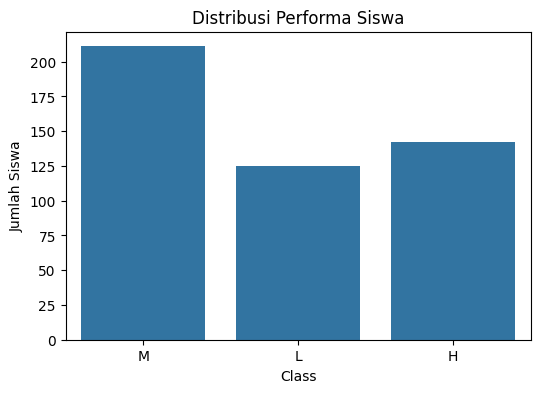

In [92]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Class',
    data=df
)

plt.title('Distribusi Performa Siswa')
plt.xlabel('Class')
plt.ylabel('Jumlah Siswa')

plt.show()

### 2. Aktivitas Digital vs Class

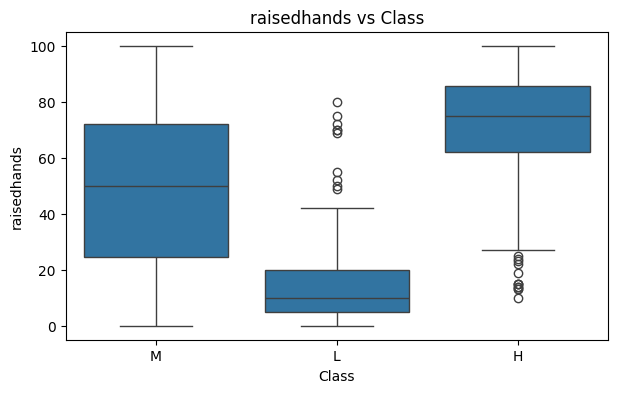

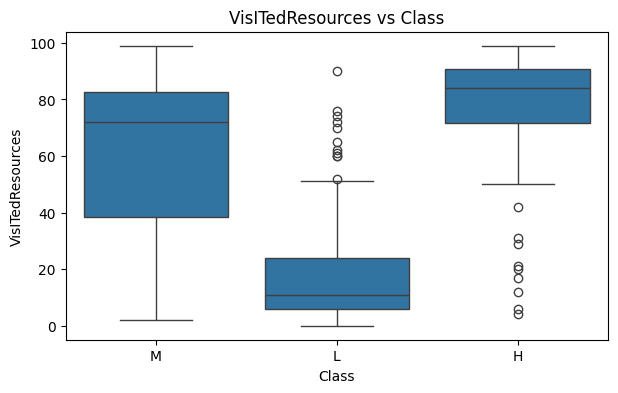

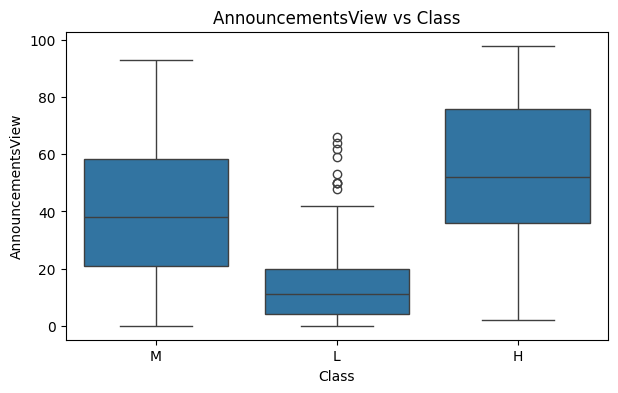

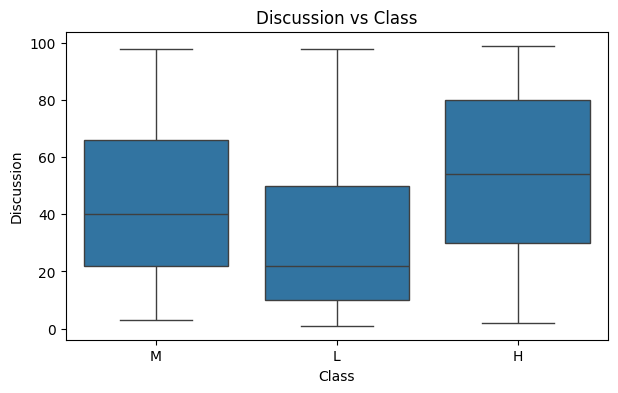

In [93]:
digital_features = [
    'raisedhands',
    'VisITedResources',
    'AnnouncementsView',
    'Discussion'
]

for feature in digital_features:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        x='Class',
        y=feature,
        data=df
    )

    plt.title(f'{feature} vs Class')
    plt.xlabel('Class')
    plt.ylabel(feature)

    plt.show()

### 3. Absensi vs Performa

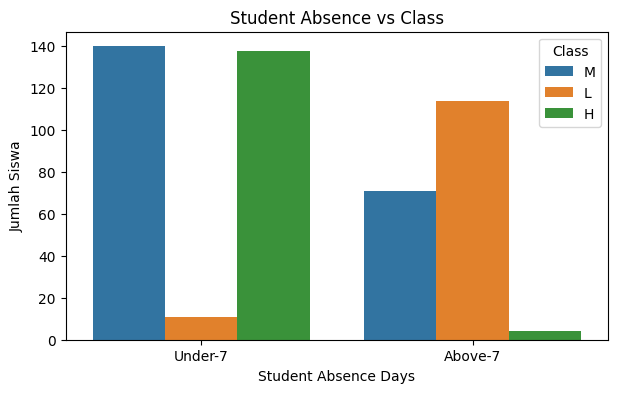

In [94]:
plt.figure(figsize=(7,4))

sns.countplot(
    x='StudentAbsenceDays',
    hue='Class',
    data=df
)

plt.title('Student Absence vs Class')
plt.xlabel('Student Absence Days')
plt.ylabel('Jumlah Siswa')

plt.show()

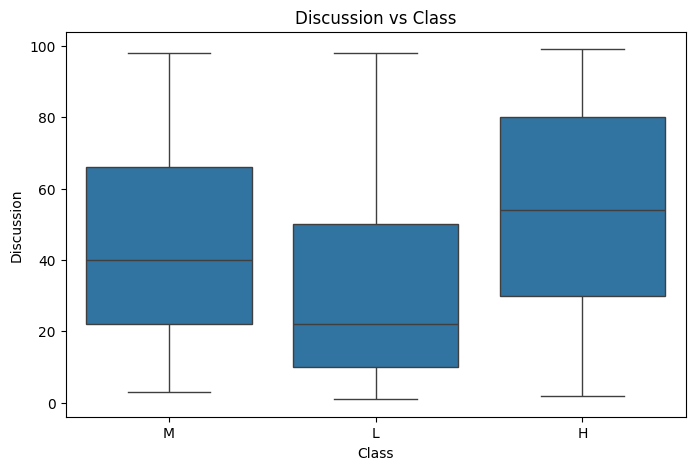

In [95]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Class',
    y='Discussion',
    data=df
)

plt.title('Discussion vs Class')
plt.xlabel('Class')
plt.ylabel('Discussion')

plt.show()

### 4. Topik vs Gender & Class


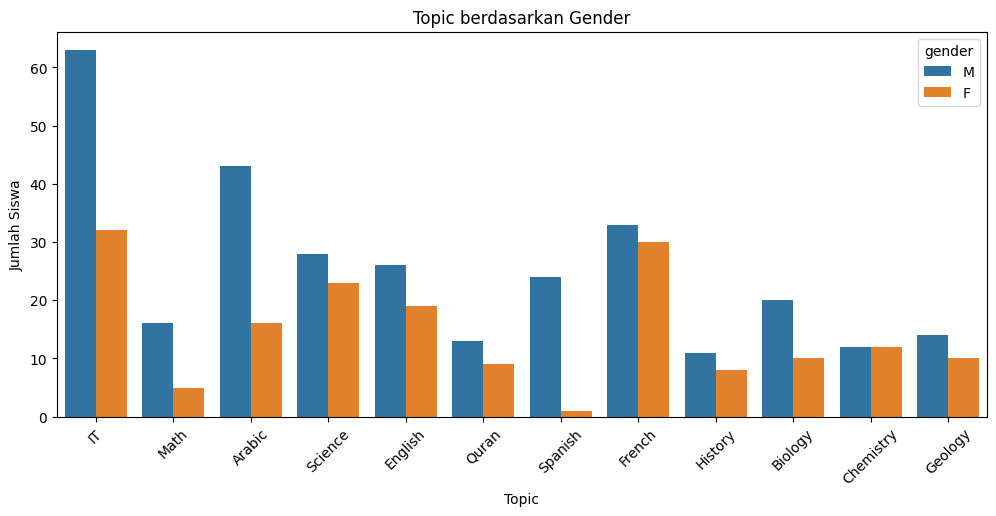

In [96]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='Topic',
    hue='gender',
    data=df
)

plt.xticks(rotation=45)

plt.title('Topic berdasarkan Gender')
plt.xlabel('Topic')
plt.ylabel('Jumlah Siswa')

plt.show()

In [97]:
topic_class = pd.crosstab(
    df['Topic'],
    df['Class']
)

topic_class

Class,H,L,M
Topic,,,
Arabic,19,17,23
Biology,16,4,10
Chemistry,10,8,6
English,17,10,18
French,20,14,29
Geology,6,0,18
History,4,3,12
IT,15,38,42
Math,6,7,8


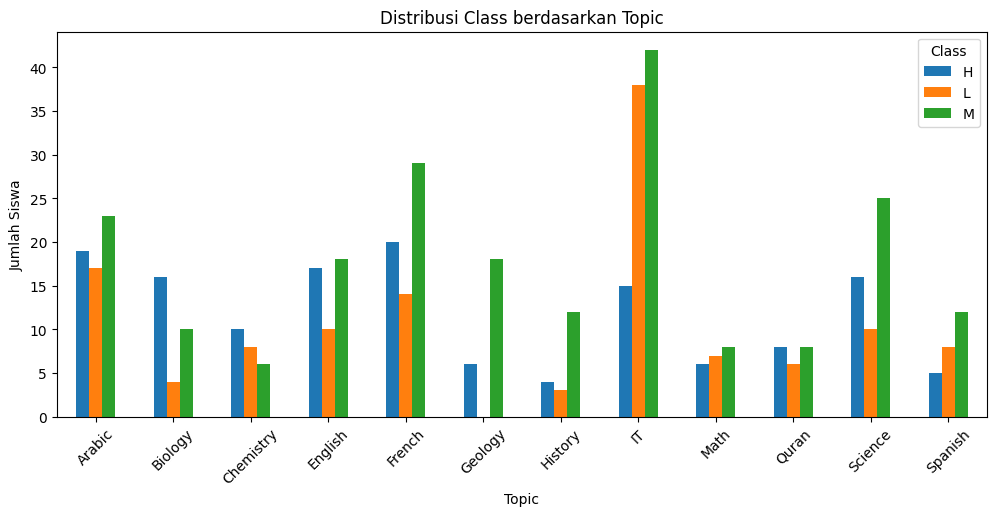

In [98]:
topic_class.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title('Distribusi Class berdasarkan Topic')
plt.xlabel('Topic')
plt.ylabel('Jumlah Siswa')

plt.xticks(rotation=45)

plt.show()

**INSIGHT**
1. Distribusi Performa Siswa:
Distribusi kategori performa siswa menunjukkan bahwa sebagian besar siswa berada pada kategori menengah hingga tinggi. Namun, masih terdapat sejumlah siswa dengan performa rendah (Class L) yang perlu mendapatkan perhatian lebih dalam proses pembelajaran. Hal ini menunjukkan bahwa sistem pembelajaran masih memiliki tantangan dalam menjaga keterlibatan seluruh siswa secara merata.

2. Hasil analisis aktivitas digital menunjukkan bahwa siswa dengan kategori performa tinggi (Class H) cenderung:

      * lebih sering membuka materi pembelajaran (VisITedResources)
      * lebih aktif berdiskusi (Discussion)
      * lebih aktif berpartisipasi di kelas (raisedhands)
      * serta lebih sering melihat pengumuman (AnnouncementsView)
Sebaliknya, siswa dengan performa rendah menunjukkan tingkat aktivitas digital yang lebih rendah.

3. Absensi dan Partisipasi Diskusi Berpengaruh Pada Risiko Nilai Rendah: Analisis menunjukkan bahwa siswa dengan jumlah ketidakhadiran tinggi (StudentAbsenceDays) cenderung berada pada kategori performa rendah (Class L). Selain itu, rendahnya partisipasi diskusi juga sering ditemukan pada siswa dengan performa rendah. Hal ini mengindikasikan bahwa kombinasi:

      * tingkat absensi tinggi
      * rendahnya interaksi pembelajaran

dapat menjadi indikator awal untuk mendeteksi siswa yang berisiko mengalami penurunan performa akademik.

4. Pada beberapa topik pelajaran tertentu, ditemukan perbedaan distribusi performa antara siswa laki-laki dan perempuan. Beberapa topik menunjukkan tingkat kesulitan yang lebih tinggi, ditandai dengan meningkatnya jumlah siswa pada kategori performa menengah dan rendah. Namun, siswa yang tetap aktif dalam interaksi pembelajaran seperti diskusi dan akses materi cenderung memiliki performa yang lebih baik meskipun berada pada topik yang lebih sulit.

# Data Preprocessing



### 1. Encoding Data Kategorikal

In [99]:
# membuat salinan dataset
df_encoded = df.copy()

# encoding data kategorikal
label_encoder = LabelEncoder()

for column in df_encoded.columns:
    if df_encoded[column].dtype == 'object':
        df_encoded[column] = label_encoder.fit_transform(df_encoded[column])

# melihat hasil encoding
df_encoded.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,1,4,4,2,1,0,7,0,0,15,16,2,20,1,1,1,2
1,1,4,4,2,1,0,7,0,0,20,20,3,25,1,1,1,2
2,1,4,4,2,1,0,7,0,0,10,7,0,30,0,0,0,1
3,1,4,4,2,1,0,7,0,0,30,25,5,35,0,0,0,1
4,1,4,4,2,1,0,7,0,0,40,50,12,50,0,0,0,2


### 2. Memisahkan Feature dan Target

In [100]:
# feature
X = df_encoded.drop('Class', axis=1)

# target
y = df_encoded['Class']

print("Shape Feature :", X.shape)
print("Shape Target  :", y.shape)

Shape Feature : (478, 16)
Shape Target  : (478,)


### 3. Train Test Split

In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data Train :", X_train.shape)
print("Data Test  :", X_test.shape)

Data Train : (382, 16)
Data Test  : (96, 16)


1. Dataset Berhasil Dibersihkan Dari Data Duplikat. Pada tahap cleaning ditemukan terdapat data duplikat pada dataset. Data tersebut kemudian dihapus menggunakan proses drop_duplicates() agar tidak menyebabkan bias pada proses pelatihan model. Dengan menghapus data duplikat, kualitas dataset menjadi lebih konsisten dan representatif terhadap kondisi sebenarnya.

2. Tidak Ditemukan Missing Value. Hasil pemeriksaan menunjukkan bahwa dataset tidak memiliki missing value pada seluruh kolom. Hal ini menunjukkan bahwa dataset memiliki kualitas yang cukup baik sehingga tidak diperlukan proses imputasi data atau penanganan nilai kosong tambahan.

3. Seluruh Data Kategorikal Berhasil Diubah Menjadi Numerik: Karena model machine learning tidak dapat memproses data bertipe kategorikal secara langsung, maka dilakukan proses encoding menggunakan LabelEncoder. Kolom kategorikal seperti:
      * gender
      * Topic
      * StageID
      * ParentAnsweringSurvey
      * StudentAbsenceDays
      * fitur kategorikal lainnya
berhasil diubah menjadi representasi numerik.Proses ini memungkinkan seluruh fitur dapat digunakan oleh model Random Forest dalam proses training.

4. Dataset Berhasil Dipisahkan Menjadi Feature dan Target, Dataset kemudian dipisahkan menjadi:
      * X sebagai feature/input model
      * y sebagai target prediksi (Class)

Target Class merepresentasikan kategori performa siswa:
High (H),
Medium (M),
Low (L).
Pemisahan ini penting agar model dapat mempelajari hubungan antara aktivitas siswa dan performa akademik mereka.

5. Data Training dan Testing Berhasil Dibagi Dengan Rasio 80:20
      * 80% data training
      * 20% data testing

Pembagian ini dilakukan menggunakan train_test_split() dengan random_state=42 agar hasil eksperimen tetap konsisten.Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk mengevaluasi performa model pada data yang belum pernah dilihat sebelumnya.

6. Dataset Sudah Siap Digunakan Untuk Machine Learning. Setelah seluruh tahapan preprocessing selesai dilakukan:

      * data sudah bersih
      * seluruh fitur sudah numerik
      * struktur dataset sudah sesuai
      * data telah dipisahkan menjadi training dan testing

Hal ini menunjukkan bahwa dataset sudah siap digunakan pada proses modeling machine learning untuk memprediksi performa akademik siswa.

# Modeling

### 1. Training Model

In [102]:
model = RandomForestClassifier(
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### 2. Prediction

In [103]:
y_pred = model.predict(X_test)

y_pred[:10]

array([2, 1, 2, 1, 1, 1, 0, 0, 2, 2])

### 3. Evaluation

**Accuracy Score**

In [109]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy Score :", accuracy)

Accuracy Score : 0.8229166666666666


**Classification Report**

In [105]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.74      0.83      0.78        24
           1       0.89      0.89      0.89        27
           2       0.83      0.78      0.80        45

    accuracy                           0.82        96
   macro avg       0.82      0.83      0.83        96
weighted avg       0.83      0.82      0.82        96



**Confusion Matrix**

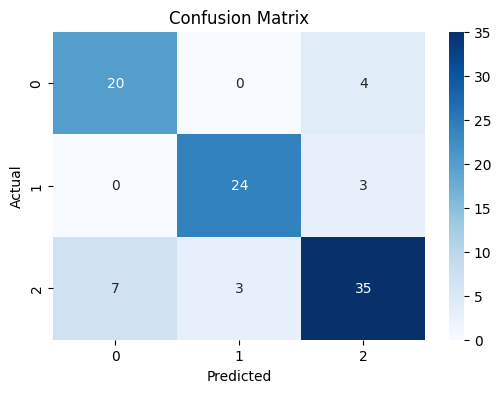

In [106]:
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### 4. Feature Importance

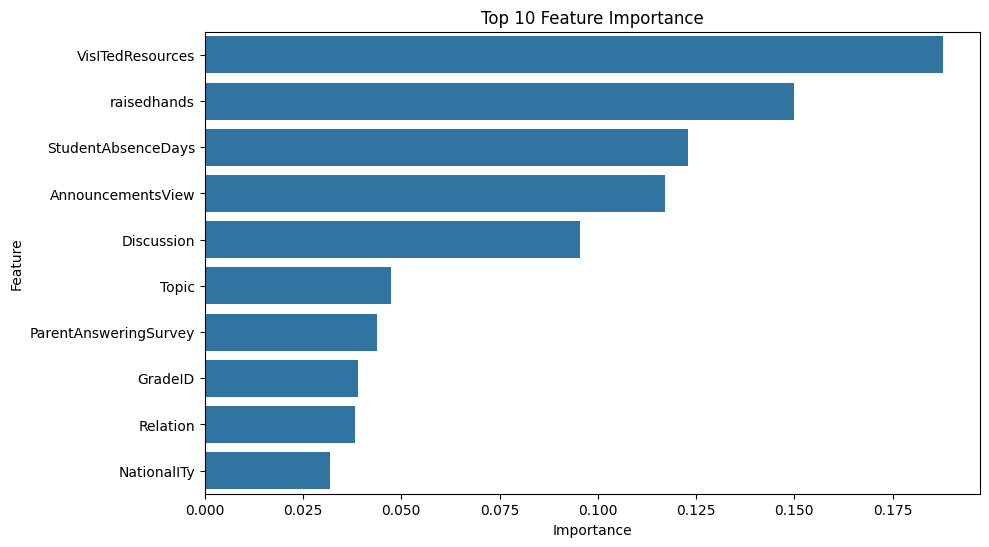

In [107]:
feature_importances = model.feature_importances_
features = X.columns

importance = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title('Top 10 Feature Importance')

plt.show()

**INSIGHT**
1. Model Random Forest Berhasil Mempelajari Pola Performa Siswa. Model Random Forest berhasil dilatih menggunakan data aktivitas pembelajaran siswa yang telah melalui tahap preprocessing. Model mampu mempelajari hubungan antara:
      * aktivitas digital siswa
      * tingkat partisipasi
      * absensi
      * interaksi pembelajaran

terhadap kategori performa akademik siswa (Class). Hal ini menunjukkan bahwa pola perilaku siswa dalam platform pembelajaran dapat digunakan untuk memprediksi performa akademik mereka.

2. Model Memiliki Accuracy Yang Cukup Baik. Hasil evaluasi menunjukkan bahwa model memperoleh accuracy sekitar 82%. Nilai accuracy ini menunjukkan bahwa model mampu melakukan prediksi dengan cukup baik terhadap kategori performa siswa. Dengan tingkat akurasi tersebut, model sudah cukup layak digunakan sebagai baseline model pada sistem pembelajaran adaptif EduPath AI.

3. Model Mampu Membedakan Kategori Performa Dengan Stabil. Berdasarkan classification report, model memiliki nilai:
      * precision
      * recall
      * f1-score

yang cukup stabil pada masing-masing kategori performa siswa. Hal ini menunjukkan bahwa model tidak hanya baik dalam memprediksi satu kategori tertentu, tetapi juga mampu membedakan siswa dengan performa tinggi, menengah, maupun rendah, secara cukup seimbang.

4. Confusion Matrix Menunjukkan Sebagian Besar Prediksi Sudah Tepat. Hasil confusion matrix menunjukkan bahwa sebagian besar data berhasil diprediksi dengan benar oleh model. Walaupun masih terdapat beberapa kesalahan prediksi antar kategori yang berdekatan seperti High menjadi Medium atau Medium menjadi Low, namun jumlah kesalahan tersebut masih relatif kecil dibandingkan jumlah prediksi yang benar. Hal ini menunjukkan bahwa model memiliki performa klasifikasi yang cukup baik.

5. Aktivitas Digital Menjadi Faktor Paling Berpengaruh berdasarkan hasil feature importance, fitur yang paling berpengaruh terhadap prediksi performa siswa adalah:
      * VisITedResources
      * raisedhands
      * Discussion

Insight ini menunjukkan bahwa tingkat engagement siswa dalam proses pembelajaran digital menjadi indikator utama keberhasilan akademik siswa. Siswa yang aktif membuka materi, aktif berdiskusi, dan aktif berpartisipasi, cenderung memiliki performa akademik yang lebih tinggi.

6. Model Dapat Digunakan Sebagai Dasar Sistem Adaptive Learning. Hasil modeling menunjukkan bahwa machine learning dapat dimanfaatkan untuk:
      * mendeteksi siswa berisiko,
      * memprediksi performa akademik,
      * memberikan rekomendasi pembelajaran personal,
      * serta membantu meningkatkan keterlibatan siswa.

Dengan demikian, model yang dikembangkan dapat menjadi dasar dalam pengembangan sistem adaptive learning pada proyek EduPath AI.

#Conclusion

Berdasarkan hasil analisis data dan proses modeling yang telah dilakukan, aktivitas digital siswa memiliki hubungan yang cukup kuat terhadap performa akademik siswa dalam proses pembelajaran.

Hasil Exploratory Data Analysis (EDA) menunjukkan bahwa siswa dengan tingkat keterlibatan tinggi seperti aktif membuka materi pembelajaran (`VisITedResources`), aktif berdiskusi (`Discussion`), serta sering berpartisipasi dalam kelas (`raisedhands`) cenderung memiliki performa akademik yang lebih baik dibandingkan siswa dengan tingkat interaksi rendah.

Selain itu, tingkat absensi yang tinggi (`StudentAbsenceDays`) juga menunjukkan hubungan terhadap meningkatnya risiko siswa berada pada kategori performa rendah (Class L). Hal ini menunjukkan bahwa keterlibatan dan konsistensi siswa dalam proses pembelajaran menjadi faktor penting dalam keberhasilan akademik.

Pada tahap preprocessing, dataset berhasil dipersiapkan dengan baik melalui proses pembersihan data, encoding fitur kategorikal, serta pembagian data training dan testing sehingga dataset siap digunakan pada proses machine learning.

Model Random Forest Classifier yang digunakan pada penelitian ini berhasil mencapai accuracy sekitar 82%, sehingga model dinilai cukup baik dalam memprediksi kategori performa siswa berdasarkan aktivitas pembelajaran mereka.

Berdasarkan hasil feature importance, fitur yang paling berpengaruh terhadap prediksi performa siswa adalah:
- `VisITedResources`
- `raisedhands`
- `Discussion`

Hasil tersebut memperkuat bahwa tingkat engagement siswa dalam pembelajaran digital merupakan faktor utama yang memengaruhi performa akademik siswa.

Secara keseluruhan, hasil analisis dan modeling pada proyek EduPath AI menunjukkan bahwa pendekatan machine learning dapat digunakan sebagai dasar dalam pengembangan sistem adaptive learning untuk:
* mendeteksi siswa berisiko,
* memberikan rekomendasi pembelajaran personal,
* membantu meningkatkan keterlibatan siswa,
* serta mendukung proses pembelajaran yang lebih adaptif dan efektif.

#Export Model

In [108]:
import pickle

# menyimpan model
pickle.dump(
    model,
    open('student_performance_model.pkl', 'wb')
)

print("Model berhasil disimpan")

Model berhasil disimpan
